<a href="https://colab.research.google.com/github/chuyuezhang2-cmd/Assignment-1-ZHANG-Chuyue/blob/main/CDS527.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CDS527 Big Data Analytics 2025-2026 Term 2
## 1 Data Loading, Cleaning, Basic Visualization + Fixed Data Split  
**Purpose:** This notebook handles the foundation of the project: loading the financial sentiment dataset, performing data cleaning, conducting basic Exploratory Data Analysis (EDA) with visualizations (bar charts, histograms, box plots, word cloud), applying a fixed train/test split with seed=42, and defining a unified evaluation function. All steps are implemented using PySpark as required. The same split and evaluation metric will be used by all group members.

### 1.1 Create Spark Session
This step creates the SparkSession, which is the unified entry point for all Spark functionality in PySpark. It is required for all subsequent data loading, transformation, and ML operations in the project.

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("CDS527_Task1_DataLoading_Cleaning_EDA_Split") \
    .getOrCreate()

spark

### 1.2 Load Dataset
This step loads the provided `data6Financial.csv` file into a PySpark DataFrame. The dataset contains financial sentences with sentiment labels (0: negative, 1: positive, 2: neutral). Loading with header and inferSchema ensures correct column types for further processing.

In [2]:
from google.colab import files
import io

# Upload the data file (run this cell and select data6Financial.csv)
uploaded = files.upload()

df = spark.read.csv(list(uploaded.keys())[0],
                    header=True,
                    inferSchema=True)

df.printSchema()
df.show(5, truncate=False)

Saving data6Financial.csv to data6Financial (1).csv
root
 |-- PhraseId: integer (nullable = true)
 |-- SentenceId: integer (nullable = true)
 |-- Phrase: string (nullable = true)
 |-- Sentiment: integer (nullable = true)

+--------+----------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+
|PhraseId|SentenceId|Phrase                                                                                                                                                                             |Sentiment|
+--------+----------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+
|110715  |5866      |` In this poor remake of such a well loved classic , Parker exposes the limitations of his skill and the basic flaws in h

### 1.3 Data Cleaning
This step performs essential data cleaning: dropping rows with null values in Phrase or Sentiment, converting text to lowercase, trimming spaces, and removing special characters. This ensures high-quality input for all subsequent models (baseline, tree-based, embeddings, etc.).

In [3]:
from pyspark.sql.functions import col, trim, lower, regexp_replace

df_clean = df.dropna(subset=["Phrase", "Sentiment"])

df_clean = df_clean.withColumn("Phrase", trim(lower(col("Phrase"))))
df_clean = df_clean.withColumn("Phrase",
                               regexp_replace(col("Phrase"), r'[^a-z0-9\s]', ''))

df_clean = df_clean.select("PhraseId", "SentenceId", "Phrase", "Sentiment")
df_clean.show(5, truncate=False)
print(f"Original rows: {df.count()}, After cleaning: {df_clean.count()}")

+--------+----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+
|PhraseId|SentenceId|Phrase                                                                                                                                                                           |Sentiment|
+--------+----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+
|110715  |5866      | in this poor remake of such a well loved classic  parker exposes the limitations of his skill and the basic flaws in his vision                                                 |0        |
|135234  |7302      |without any redeeming value whatsoever                                                                                                     

### 1.4 Basic EDA - Sentiment Distribution
This step generates statistical summary and visualization (bar chart) of the Sentiment label distribution. It helps understand class balance/imbalance, which is critical for choosing appropriate models and improvement methods later in the project.

/tmp/ipykernel_2723/3623204259.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_dist, x="Sentiment", y="count", palette="viridis")


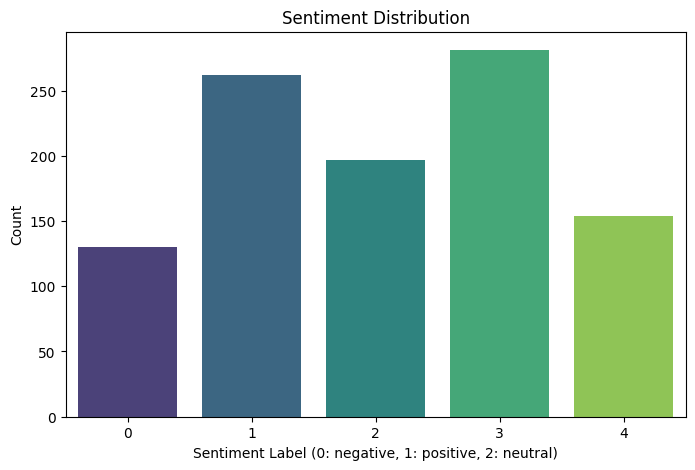

,Sentiment,count
0,0,130
1,1,262
2,2,197
3,3,281
4,4,154


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sentiment_dist = df_clean.groupBy("Sentiment").count().orderBy("Sentiment").toPandas()

plt.figure(figsize=(8,5))
sns.barplot(data=sentiment_dist, x="Sentiment", y="count", palette="viridis")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Label (0: negative, 1: positive, 2: neutral)")
plt.ylabel("Count")
plt.show()

sentiment_dist

### 1.5 Basic EDA - Sentence Length Statistics
This step calculates sentence length (in words) and provides central tendency (mean, median) and dispersion statistics (std, quartiles, min, max). It also visualizes the distribution with a histogram and boxplot. These statistics describe data patterns as required in Task 1 point 4.

+-------+-----------------+
|summary|       word_count|
+-------+-----------------+
|  count|             1024|
|   mean|        19.171875|
| stddev|9.640444597787528|
|    min|                1|
|    max|               51|
+-------+-----------------+

Q1 (25%): 11.0, Median (50%): 18.0, Q3 (75%): 25.0


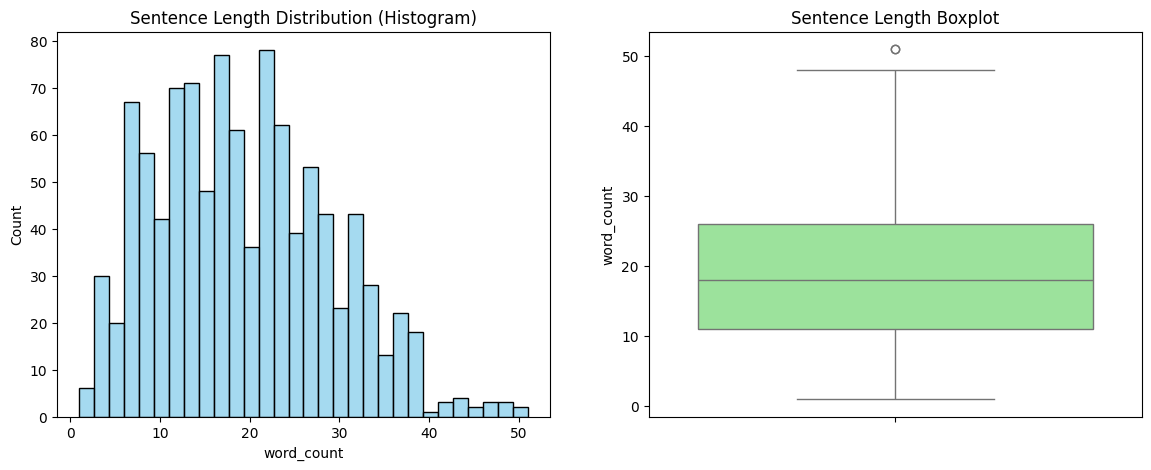

In [5]:
from pyspark.sql.functions import size, split

df_len = df_clean.withColumn("word_count", size(split(col("Phrase"), " ")))

df_len.select("word_count").describe().show()

quartiles = df_len.approxQuantile("word_count", [0.25, 0.5, 0.75], 0.01)
print(f"Q1 (25%): {quartiles[0]}, Median (50%): {quartiles[1]}, Q3 (75%): {quartiles[2]}")

pdf_len = df_len.select("word_count").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(pdf_len["word_count"], bins=30, ax=axes[0], color="skyblue")
axes[0].set_title("Sentence Length Distribution (Histogram)")
sns.boxplot(y=pdf_len["word_count"], ax=axes[1], color="lightgreen")
axes[1].set_title("Sentence Length Boxplot")
plt.show()

### 1.6 Basic EDA - Overall Word Cloud
This step creates a word cloud of all phrases to visually show the most frequent words across the entire dataset. This is one of the visualization techniques (as mentioned in Task 1 point 4) to discover patterns in the textual data.

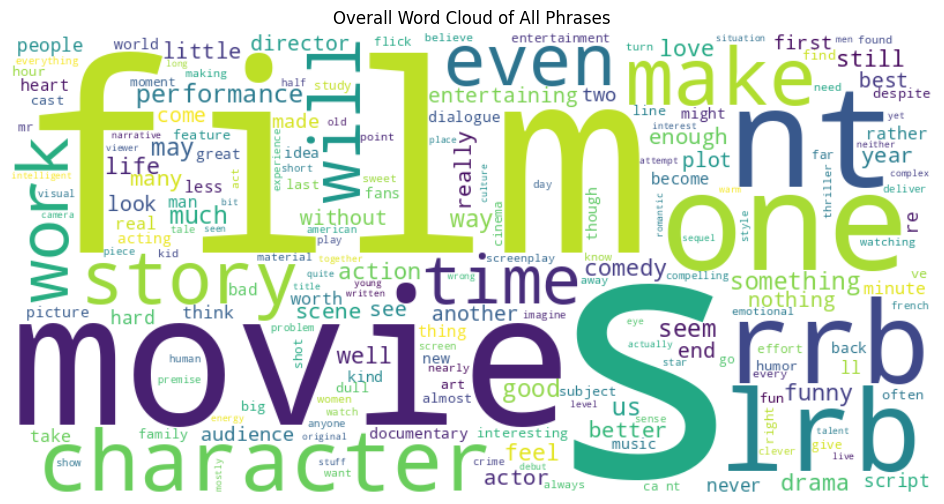

In [6]:
from wordcloud import WordCloud

all_text = " ".join(df_clean.select("Phrase").rdd.flatMap(lambda x: x).collect())

wordcloud = WordCloud(width=800, height=400, background_color="white", max_words=200).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Overall Word Cloud of All Phrases")
plt.show()

### 1.7 Fixed Train/Test Split (80/20, seed=42)
This step applies a fixed random split (80% train, 20% test) with seed=42. This is **mandatory** for the entire group — all models (baseline, Decision Tree, GBT, BERT, etc.) must use exactly this same split to ensure fair comparison and consistent evaluation as required by the project.

In [11]:
# Better saving with full path
train_data.write.mode("overwrite").parquet("/content/train_data")
test_data.write.mode("overwrite").parquet("/content/test_data")

print("✅ Successfully saved train_data and test_data as parquet!")

✅ Successfully saved train_data and test_data as parquet!


### 1.8 Define Unified Evaluation Function
This step defines a reusable function to compute Accuracy + Weighted F1-score and display the confusion matrix. Every model in the group (including baseline, tree models, BERT-enhanced models, and improved models) **must use this exact function** to report scores. This guarantees the same evaluation metric throughout the project.

In [12]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics

def evaluate_model(predictions_df, label_col="Sentiment", prediction_col="prediction"):
    """
    predictions_df: must contain both label_col and prediction_col
    Returns: accuracy, weighted_f1
    Prints: Accuracy, Weighted F1-score, and Confusion Matrix
    """
    evaluator_acc = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol=prediction_col,
        metricName="accuracy")

    evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol=prediction_col,
        metricName="weightedFMeasure")

    accuracy = evaluator_acc.evaluate(predictions_df)
    weighted_f1 = evaluator_f1.evaluate(predictions_df)

    print(f"Accuracy = {accuracy:.4f}")
    print(f"Weighted F1-score = {weighted_f1:.4f}")

    results_rdd = predictions_df.select(prediction_col, label_col).rdd.map(lambda row: (float(row[0]), float(row[1])))
    metrics = MulticlassMetrics(results_rdd)
    cm = metrics.confusionMatrix().toArray()
    print("\nConfusion Matrix:")
    print(cm)

    return accuracy, weighted_f1

In [13]:
# Package train_data and test_data into a zip file.
!zip -r train_test_data.zip train_data test_data

print("✅ Packaging complete! Generated file: train_test_data.zip")

  adding: train_data/ (stored 0%)
  adding: train_data/._SUCCESS.crc (stored 0%)
  adding: train_data/part-00000-ff57adb9-890f-4557-870e-ee9ed400b482-c000.snappy.parquet (deflated 17%)
  adding: train_data/_SUCCESS (stored 0%)
  adding: train_data/.part-00000-ff57adb9-890f-4557-870e-ee9ed400b482-c000.snappy.parquet.crc (stored 0%)
  adding: test_data/ (stored 0%)
  adding: test_data/._SUCCESS.crc (stored 0%)
  adding: test_data/_SUCCESS (stored 0%)
  adding: test_data/part-00000-56045f35-937d-448c-ad4e-c9621ec04b99-c000.snappy.parquet (deflated 19%)
  adding: test_data/.part-00000-56045f35-937d-448c-ad4e-c9621ec04b99-c000.snappy.parquet.crc (stored 0%)
✅ Packaging complete! Generated file: train_test_data.zip
